TypeError: cannot directly convert an xarray.Dataset into a numpy array. Instead, create an xarray.DataArray first, either with indexing on the Dataset or by invoking the `to_dataarray()` method.

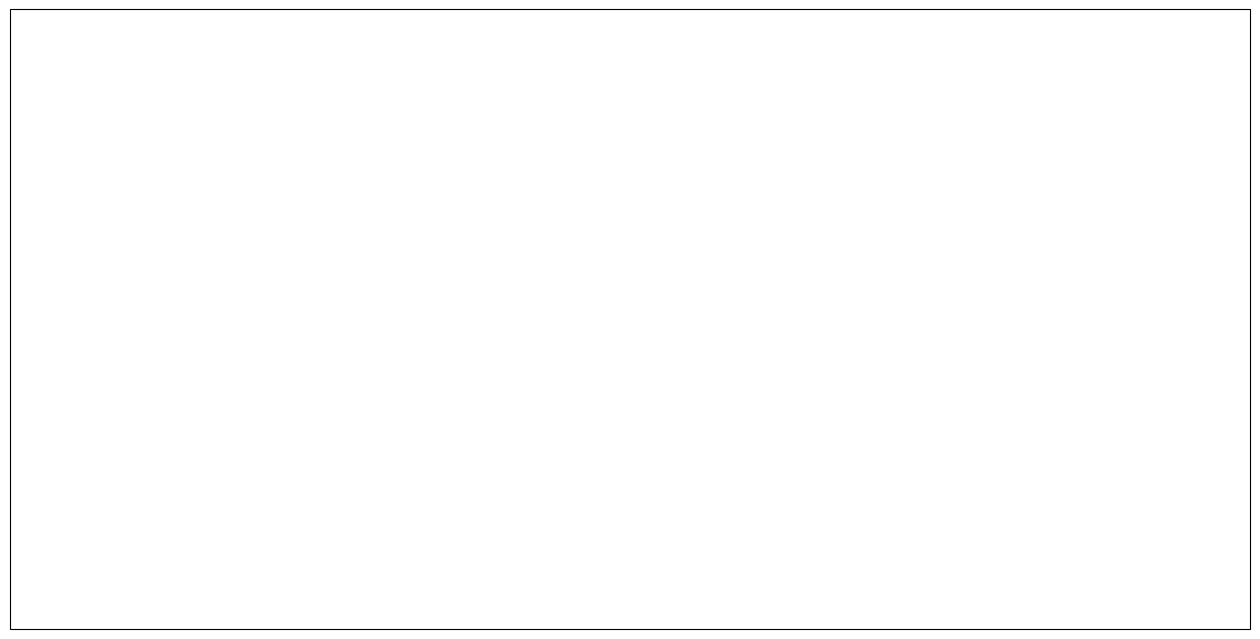

In [16]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import cartopy.crs as ccrs
import sys

# qsub -I -q normal -P er8 -l walltime=1:00:00,ncpus=24,mem=120GB,jobfs=100MB,storage=gdata/xp65+gdata/er8+gdata/ob53+gdata/rt52+gdata/rv74

wf = 'cycmask'

# Load datasets
file_path = Path(f'/g/data/er8/users/cd3022/Irradiance-comparisons/weather-features/{wf}')
him_files = [f for f in file_path.glob('himawari*.nc')]
barra_files = [f for f in file_path.glob('barra-r2*.nc')]
him = xr.open_mfdataset(him_files, combine='nested', concat_dim='year')
bar = xr.open_mfdataset(barra_files, combine='nested', concat_dim='year')

him = him.mean(dim='year')
bar = bar.mean(dim='year')

him = him.interp(
    lat=bar.lat,
    lon=bar.lon,
    method='linear'
)

diff = bar - him


fig, ax = plt.subplots(figsize=(16,10), subplot_kw={'projection': ccrs.PlateCarree()})

mesh = ax.pcolormesh(
    diff.lon,
    diff.lat,
    diff,
    cmap='RdBu_r', shading='auto',
    vmin=-40, vmax=40,
    transform=ccrs.PlateCarree()
)
ax.coastlines()
fig.suptitle(f'BARRA-R2 - Himwari {wf}', fontsize=18)
cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label("Surface Downward SW bias (W/m²)")
plt.savefig(f'/home/548/cd3022/figures/Irradiance_comparisons/weather-features/barra-r2_himawari_{wf}.png')

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import sys
sys.path.append('/home/548/cd3022/repos/Irradiance-comparisons/Irradiance-comparisons/')
from read_datasets import read_dataset

# qsub -I -q normal -P er8 -l walltime=4:00:00,ncpus=24,mem=120GB,jobfs=100MB,storage=gdata/xp65+gdata/er8+gdata/ob53+gdata/rt52+gdata/rv74+scratch/er8

In [2]:
year=2020
month=1

# LOAD DATASETS
barra = read_dataset(
        dataset='barra-r2',
        resolution='hourly',
        date=f'{year}-{month:02d}'
    )

himawari = read_dataset(
    dataset='himawari',
    resolution='hourly',
    date=f'{year}-{month:02d}'
)

2026-01-22 12:04:36,573:py.warnings:WARNING: /g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'kerchunk' loading failed:
No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)

No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)

2026-01-22 12:06:20,410:py.warnings:WARNING: /home/548/cd3022/repos/Irradiance-comparisons/Irradiance-comparisons/read_datasets.py:77: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or

In [3]:
wf = 'acycmask'

if wf == 'frovo_id':
    lvl = 850
else:
    lvl = 'sfc'

def preprocess(ds):
    return ds.sel(
        latitude=slice(barra.lat.max(), barra.lat.min()),
        longitude=slice(barra.lon.min(), barra.lon.max())
    ).rename(
        {'latitude':'lat',
        'longitude':'lon'}
    )

wf_path = Path(f'/scratch/er8/cd3022/weather-features/cyc-anticyc-front-cao/')
wf_files = [f for f in wf_path.glob(f'*{year}{month:02d}.{lvl}.{wf}.nc')]
wf_ds = xr.open_mfdataset(wf_files, preprocess=preprocess)

if wf == 'frovo_id':
    wf_ds = wf_ds.isel(lev=0)

wf_ds[wf]

<xarray.DataArray 'acycmask' (time: 248, lat: 68, lon: 88)> Size: 1MB
dask.array<getitem, shape=(248, 68, 88), dtype=int8, chunksize=(83, 41, 88), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 2kB 2020-01-01 ... 2020-01-31T21:00:00
  * lat      (lat) float32 272B -10.5 -11.0 -11.5 -12.0 ... -43.0 -43.5 -44.0
  * lon      (lon) float32 352B 112.5 113.0 113.5 114.0 ... 155.0 155.5 156.0
Attributes:
    long_name:  Anticyclone detection mask
    units:      (0-1)

In [4]:
# PREPROCESS DATASETS TO MATCH TIMES/SHAPES
# interp him to barra
himawari = himawari.interp(
    lat=barra.lat,
    lon=barra.lon,
    method='nearest'
)

# interp wf mask from era5 to barra
wf_ds = wf_ds.interp(
    lat=barra.lat,
    lon=barra.lon,
    method='nearest'
)

# fill missing time steps
full_time = pd.date_range(
    start=himawari.time.min().item(),
    end=himawari.time.max().item(),
    freq="60min"
)
himawari = himawari.reindex(time=full_time, fill_value=0)

#

# adjust hourly times on the 30min to match 3hr times (on the hour) from wf
barra_shifted = barra.assign_coords(time=barra.time - pd.Timedelta('30min'))
barra_times = barra_shifted.sel(time=wf_ds.time)

himawari_shifted = himawari.assign_coords(time=himawari.time - pd.Timedelta('30min'))
himawari_times = himawari_shifted.sel(time=wf_ds.isel(time=slice(0, -4)).time)

In [5]:
# APPLY MASK
barra_wf_ghi = xr.where(wf_ds[wf] != 0, barra_times.ghi, np.nan)
himawari_wf_ghi = xr.where(wf_ds.isel(time=slice(0, -4))[wf] != 0, himawari_times.ghi, np.nan)

# TIME MEAN
barra_wf_mean = barra_wf_ghi.mean(dim='time')
himawari_wf_mean = himawari_wf_ghi.mean(dim='time')

diff = barra_wf_mean - himawari_wf_mean
diff = xr.where(himawari.isel(time=4).ghi.isnull(), np.nan, diff)

In [6]:
diff.attrs['comment'] = 'this is a test comment'

In [7]:
import datetime
datetime.date.today().strftime('%D')

'01/22/26'

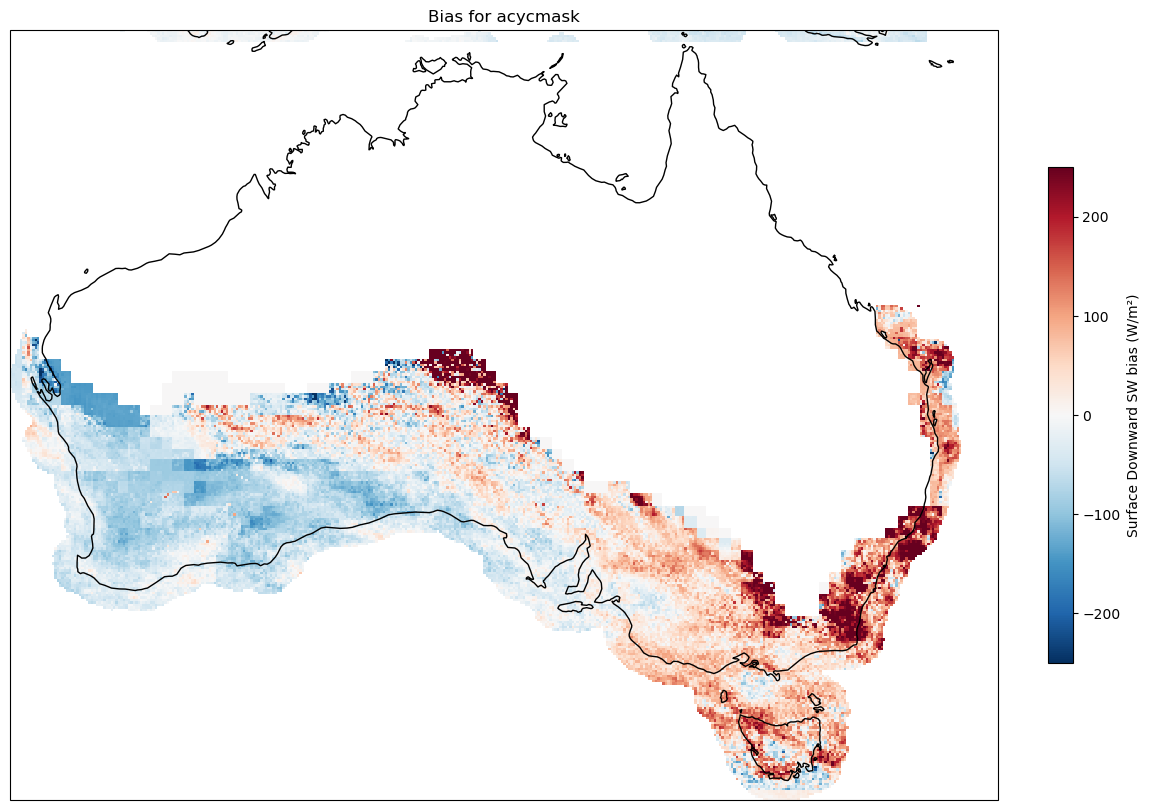

In [8]:
# PLOT
fig, ax = plt.subplots(figsize=(16,10), subplot_kw={'projection': ccrs.PlateCarree()})
mesh = ax.pcolormesh(
    diff.lon,
    diff.lat,
    diff,
    cmap='RdBu_r',
    vmin=-250, vmax=250,
    shading='auto',
    transform=ccrs.PlateCarree()
)
ax.coastlines()
ax.set_title(f'Bias for {wf}')
cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label("Surface Downward SW bias (W/m²)")
# plt.savefig('/home/548/cd3022/figures/Irradiance_comparisons/weather-features/cyc-2020-01.png')
plt.show()

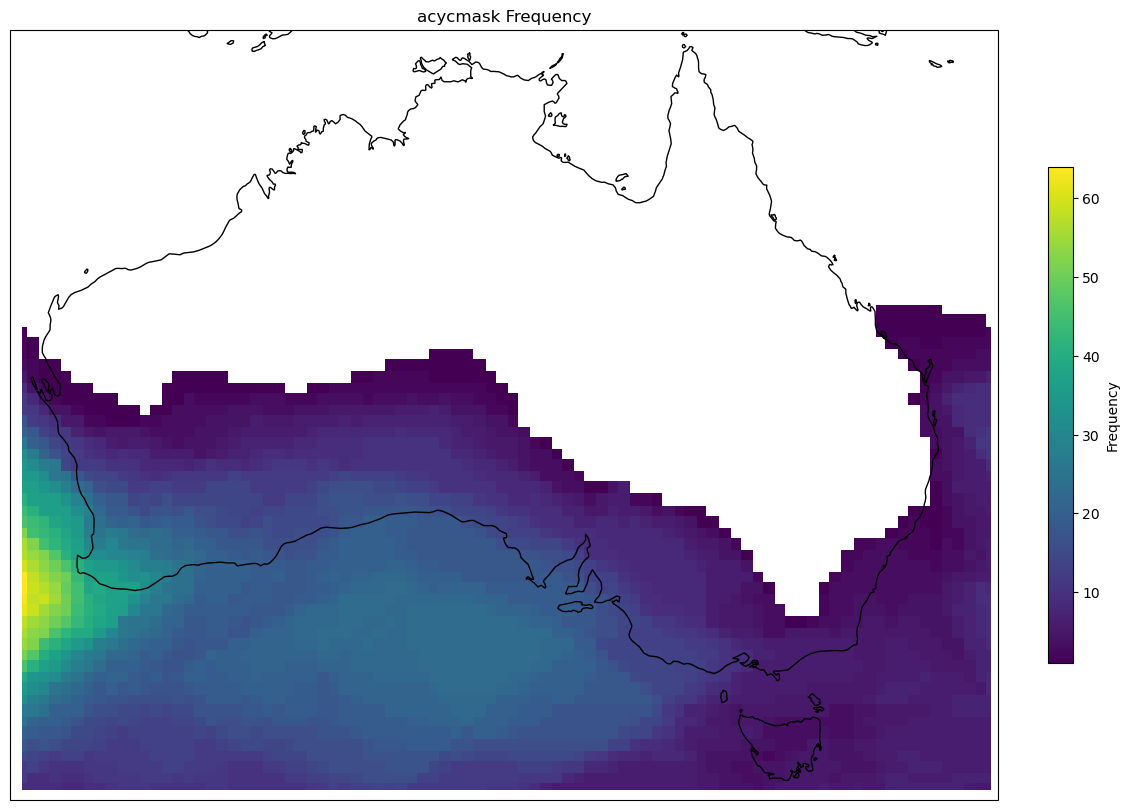

In [10]:
# PLOT
tot_wf = wf_ds[wf].sum(dim='time')
tot_wf = xr.where(tot_wf == 0, np.nan, tot_wf)
fig, ax = plt.subplots(figsize=(16,10), subplot_kw={'projection': ccrs.PlateCarree()})
mesh = ax.pcolormesh(
    tot_wf.lon,
    tot_wf.lat,
    tot_wf,
    cmap='viridis',
    shading='auto',
    transform=ccrs.PlateCarree()
)
ax.coastlines()
ax.set_title(f'{wf} Frequency')
cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label("Frequency")
# plt.savefig('/home/548/cd3022/figures/Irradiance_comparisons/weather-features/cyc-freq-2020-01.png')
plt.show()